<a href="https://colab.research.google.com/github/abhishek18-blog/DataScience-and-ML/blob/main/perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, classification_report

# Load the dataset
try:
    df = pd.read_csv('/content/survey lung cancer.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: 'survey lung cancer.csv' not found. Please make sure the file is in the '/content/' directory.")
    # Exit or handle the error appropriately
    exit()

# Display the first few rows and information about the dataset
display(df.head())
print(df.info())


Dataset loaded successfully.


,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   GENDER                 309 non-null    object
 1   AGE                    309 non-null    int64 
 2   SMOKING                309 non-null    int64 
 3   YELLOW_FINGERS         309 non-null    int64 
 4   ANXIETY                309 non-null    int64 
 5   PEER_PRESSURE          309 non-null    int64 
 6   CHRONIC DISEASE        309 non-null    int64 
 7   FATIGUE                309 non-null    int64 
 8   ALLERGY                309 non-null    int64 
 9   WHEEZING               309 non-null    int64 
 10  ALCOHOL CONSUMING      309 non-null    int64 
 11  COUGHING               309 non-null    int64 
 12  SHORTNESS OF BREATH    309 non-null    int64 
 13  SWALLOWING DIFFICULTY  309 non-null    int64 
 14  CHEST PAIN             309 non-null    int64 
 15  LUNG_CANCER            

### Preprocessing the Data

1.  **Handle Categorical Features**: Convert 'GENDER' and 'LUNG_CANCER' into numerical representations using `LabelEncoder`.
2.  **Separate Features and Target**: Define `X` (features) and `y` (target).
3.  **Split Data**: Divide the dataset into training and testing sets.
4.  **Feature Scaling**: Scale numerical features to ensure all features contribute equally to the model's training process.

In [2]:
# Encode 'GENDER' column
le_gender = LabelEncoder()
df['GENDER'] = le_gender.fit_transform(df['GENDER'])

# Encode 'LUNG_CANCER' (target variable)
# Assuming 'YES' is 1 and 'NO' is 0
le_lung_cancer = LabelEncoder()
df['LUNG_CANCER'] = le_lung_cancer.fit_transform(df['LUNG_CANCER'])

# Define features (X) and target (y)
X = df.drop('LUNG_CANCER', axis=1)
y = df['LUNG_CANCER']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data preprocessing complete. Shapes of datasets:")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test_scaled: {X_test_scaled.shape}")
print(f"y_test: {y_test.shape}")


Data preprocessing complete. Shapes of datasets:
X_train_scaled: (216, 15)
y_train: (216,)
X_test_scaled: (93, 15)
y_test: (93,)


### Single-Layer Perceptron Model

1.  **Initialize Perceptron**: Create an instance of the `Perceptron` classifier.
2.  **Train the Model**: Fit the model to the scaled training data.
3.  **Make Predictions**: Use the trained model to predict on the scaled test data.
4.  **Evaluate Performance**: Calculate and display the accuracy score and a classification report to assess the model's performance.

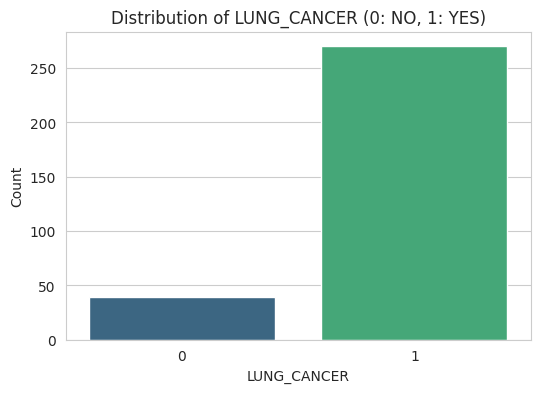

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_style("whitegrid")

# 1. Distribution of the target variable (LUNG_CANCER)
plt.figure(figsize=(6, 4))
sns.countplot(x='LUNG_CANCER', data=df, palette='viridis', hue='LUNG_CANCER', legend=False)
plt.title('Distribution of LUNG_CANCER (0: NO, 1: YES)')
plt.xlabel('LUNG_CANCER')
plt.ylabel('Count')
plt.show()

The plot above shows the distribution of the target variable, `LUNG_CANCER`. It indicates a class imbalance, with a significantly higher number of 'YES' cases (encoded as 1) than 'NO' cases (encoded as 0).

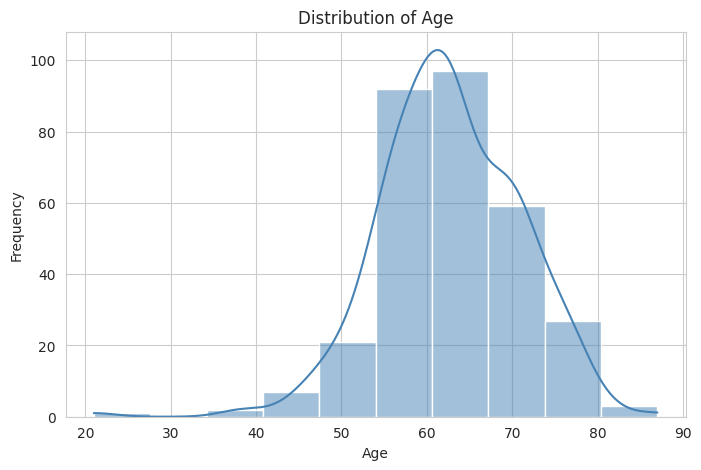

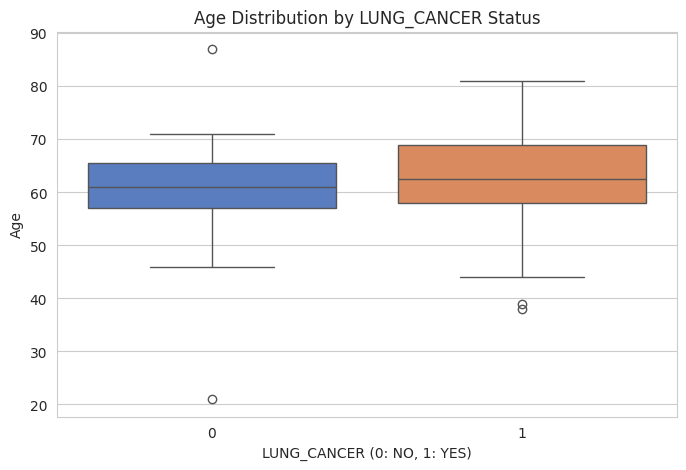

In [8]:
# 2. Distribution of Age
plt.figure(figsize=(8, 5))
sns.histplot(df['AGE'], bins=10, kde=True, color='steelblue') # Changed palette to color for histplot
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# 3. Age vs LUNG_CANCER
plt.figure(figsize=(8, 5))
sns.boxplot(x='LUNG_CANCER', y='AGE', data=df, palette='muted', hue='LUNG_CANCER', legend=False) # Added hue for boxplot
plt.title('Age Distribution by LUNG_CANCER Status')
plt.xlabel('LUNG_CANCER (0: NO, 1: YES)')
plt.ylabel('Age')
plt.show()

The age distribution shows the range of ages in the dataset, and the boxplot helps visualize if there's a difference in age between individuals with and without lung cancer.

The correlation matrix provides insights into the relationships between all variables in the dataset. Values close to 1 or -1 indicate a strong positive or negative correlation, respectively, while values close to 0 suggest a weak correlation.

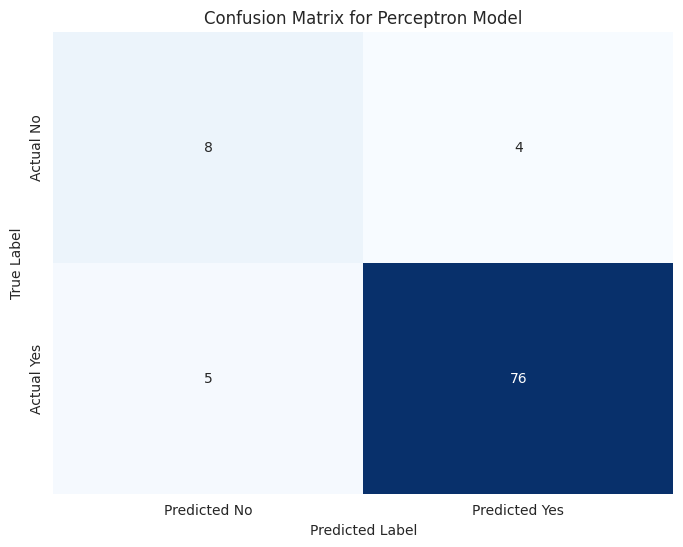

In [9]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Create a DataFrame for better labeling in the heatmap
cm_df = pd.DataFrame(cm, index=['Actual No', 'Actual Yes'], columns=['Predicted No', 'Predicted Yes'])

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix for Perceptron Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


This confusion matrix visualizes the performance of the Perceptron model:
*   **True Negatives (Top-Left)**: Correctly predicted 'NO' cases.
*   **False Positives (Top-Right)**: Incorrectly predicted 'YES' cases (actual 'NO').
*   **False Negatives (Bottom-Left)**: Incorrectly predicted 'NO' cases (actual 'YES').
*   **True Positives (Bottom-Right)**: Correctly predicted 'YES' cases.

In [3]:
# Initialize the Perceptron model
# random_state for reproducibility, eta0 is the learning rate
perceptron_model = Perceptron(random_state=42, eta0=0.1, max_iter=1000)

# Train the model
perceptron_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred = perceptron_model.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy of the Perceptron model: {accuracy:.4f}")
print("\nClassification Report:")
print(report)

# To see what 'YES' and 'NO' map to:
print(f"\nLabel encoding for LUNG_CANCER: {list(le_lung_cancer.classes_)} -> {list(range(len(le_lung_cancer.classes_)))}")


Accuracy of the Perceptron model: 0.9032

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.67      0.64        12
           1       0.95      0.94      0.94        81

    accuracy                           0.90        93
   macro avg       0.78      0.80      0.79        93
weighted avg       0.91      0.90      0.90        93


Label encoding for LUNG_CANCER: ['NO', 'YES'] -> [0, 1]
